In [33]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split #imports

In [32]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Model #imports

In [7]:
!wget https://lazyprogrammer.me/course_files/spam.csv



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://lazyprogrammer.me/cour]87Saving 'spam.csv'
87spam.csv               4% [>                             ]   21.36K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87spam.csv             100% [=============================>]  491.85K  861.70KB/s87HTTP response 200  [https://lazyprogrammer.me/course_files/spam.csv]
87spam.csv             100% [=============================>]  491.85K  861.70KB/s87[Files: 1  Bytes: 491.85K [317.]8

In [9]:
df = pd.read_csv('spam.csv', encoding = 'ISO-8859-1') #pegando o csv e transformando em dataframe

In [11]:
df.head() #cabeca do df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4" ], axis = 1) #excluindo colunas

In [13]:
df.head() #cabeca do df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.columns = ['labels', 'data'] #mudando nome das colunas

In [15]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df['b_labels'] = df['labels'].map({'ham' : 0, 'spam': 1}) #cria colunas binarias
Y = df['b_labels'].values

In [18]:
df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size = 0.33) #seprando em treino e teste

In [19]:
MAX_VOCAB_SIZE = 20000 #tamanho maximo da palavra
tokenizer = Tokenizer(num_words = MAX_VOCAB_SIZE) #criando o tokenizer
tokenizer.fit_on_texts(df_train) #passando os dados de treino
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test) #colocando os dados em vetores cada palavra um numero no vetor

In [20]:
word2idx = tokenizer.word_index #dicionario
V = len(word2idx) #pega quantas palavras
print("Found %s unique tokens." % V) 

Found 7164 unique tokens.


In [21]:
data_train = pad_sequences(sequences_train) #preenche pra tudo ficar do msm tamanho
print('Shape of data train tensor: ', data_train.shape)

Shape of data train tensor:  (3733, 189)


In [22]:
T = data_train.shape[1] #pega o tamanho da sequencia

In [25]:
data_test = pad_sequences(sequences_test, maxlen = T) #todos tem o tamanho de T
data_test.shape

(1839, 189)

In [26]:
D = 20

i = Input(shape = (T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation = 'relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation = 'relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation = 'relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation = 'sigmoid')(x) #faz a rede

model = Model(i, x) #define modelo

W0000 00:00:1781113705.538862  220051 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [27]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy']) #compila

r = model.fit(data_train, Ytrain, epochs = 5, validation_data = (data_test, Ytest)) #treina

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8669 - loss: 0.3669 - val_accuracy: 0.9130 - val_loss: 0.2125
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.0979 - val_accuracy: 0.9772 - val_loss: 0.0852
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9922 - loss: 0.0281 - val_accuracy: 0.9772 - val_loss: 0.0731
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9965 - loss: 0.0099 - val_accuracy: 0.9788 - val_loss: 0.0788
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: 0.0038 - val_accuracy: 0.9782 - val_loss: 0.1078


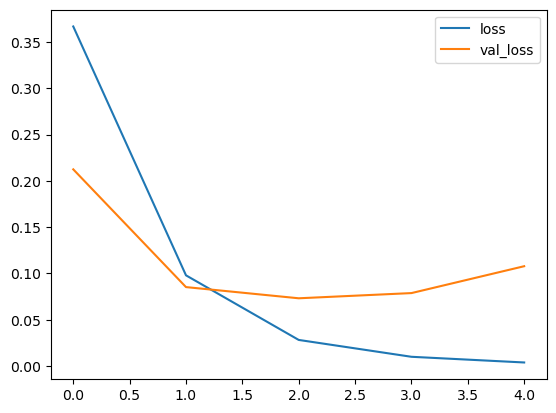

In [28]:
plt.plot(r.history['loss'], label = 'loss')
plt.plot(r.history['val_loss'], label = 'val_loss') #grafico que compara validation loss e loss
plt.legend()

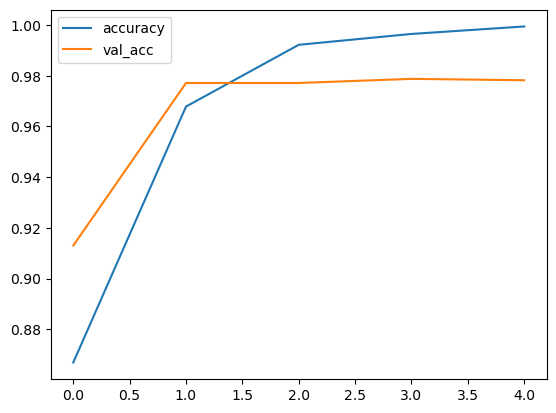

In [29]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc') #compara acuracia com validation accuracy
plt.legend()